감정 분석할 이미지 업로드


Saving vitalii-khodzinskyi--PccdxzXd9o-unsplash.jpg to vitalii-khodzinskyi--PccdxzXd9o-unsplash.jpg


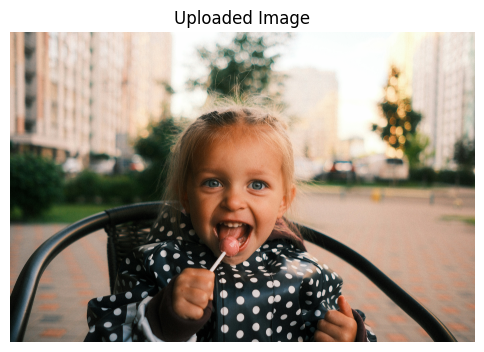


감정 인식 결과
 Emotion  Percentage
   happy   83.230003
    fear   13.250000
     sad    2.580000
surprise    0.550000
   angry    0.390000
 disgust    0.000000
 neutral    0.000000

가장 높은 감정:
happy


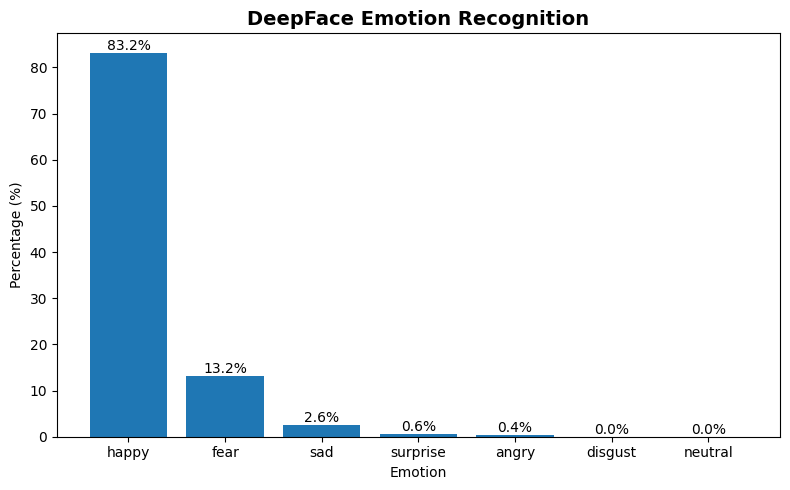


감정 순위
1. happy : 83.23%
2. fear : 13.25%
3. sad : 2.58%
4. surprise : 0.55%
5. angry : 0.39%
6. disgust : 0.00%
7. neutral : 0.00%


In [2]:
# ============================================================
# DeepFace 감정 인식 분석 (Google Colab)
# 업로드된 사진의 감정 비율 분석
# ============================================================

# ------------------------------------------------------------
# 라이브러리 설치
# ------------------------------------------------------------

!pip -q install deepface
!pip -q install tf-keras

# ------------------------------------------------------------
# 라이브러리
# ------------------------------------------------------------

from deepface import DeepFace
from google.colab import files
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 이미지 업로드
# ------------------------------------------------------------

print("="*60)
print("감정 분석할 이미지 업로드")
print("="*60)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ------------------------------------------------------------
# 이미지 표시
# ------------------------------------------------------------

img = Image.open(file_name)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

# ------------------------------------------------------------
# DeepFace 감정 분석
# ------------------------------------------------------------

result = DeepFace.analyze(
    img_path=file_name,
    actions=['emotion'],
    enforce_detection=False
)

# 얼굴이 하나인 경우 처리
if isinstance(result, list):
    result = result[0]

emotion_scores = result["emotion"]

# ------------------------------------------------------------
# 결과 출력
# ------------------------------------------------------------

print("\n" + "="*60)
print("감정 인식 결과")
print("="*60)

emotion_df = pd.DataFrame(
    emotion_scores.items(),
    columns=["Emotion", "Percentage"]
)

emotion_df["Percentage"] = emotion_df["Percentage"].round(2)
emotion_df = emotion_df.sort_values(
    by="Percentage",
    ascending=False
)

print(emotion_df.to_string(index=False))

print("\n가장 높은 감정:")
print(f"{result['dominant_emotion']}")

# ------------------------------------------------------------
# 감정 비율 그래프
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    emotion_df["Emotion"],
    emotion_df["Percentage"]
)

plt.title(
    "DeepFace Emotion Recognition",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Emotion")
plt.ylabel("Percentage (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 감정 순위 출력
# ------------------------------------------------------------

print("\n" + "="*60)
print("감정 순위")
print("="*60)

for idx, row in enumerate(emotion_df.itertuples(), start=1):
    print(f"{idx}. {row.Emotion} : {row.Percentage:.2f}%")